# Freeze Frame Analysis: Visualizing All 22 Player Positions

This notebook explores the `freeze_frame_format.json` files in the merged_data folder, which contain complete player positioning data for all 22 players on the field at the moment of each event.

## 1. Setup and Imports

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mplsoccer import Pitch
import warnings
warnings.filterwarnings('ignore')

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 10)

## 2. Load Freeze Frame Data

In [2]:
# Load the first match's freeze frame data (match 1410827)
freeze_frame_path = 'data/merged_data/1410827/freeze_frame_format.json'

with open(freeze_frame_path, 'r') as f:
    freeze_frames = json.load(f)

print(f"Number of freeze frames: {len(freeze_frames)}")
print(f"\nFirst freeze frame keys: {freeze_frames[0].keys()}")

Number of freeze frames: 3639

First freeze frame keys: dict_keys(['frame', 'timestamp', 'period', 'ball_data', 'possession', 'image_corners_projection', 'player_data', 'statsbomb_event_id', 'statsbomb_event_type', 'player_id', 'statsbomb_player_id', 'team_id', 'statsbomb_team_id', 'is_matched', 'is_player_detected', 'projected_statsbomb_event_x', 'projected_statsbomb_event_y'])


## 3. Explore Freeze Frame Structure

In [3]:
# Examine a sample frame
sample_frame = freeze_frames[100]

print("Sample Freeze Frame Structure:")
print(f"Frame: {sample_frame['frame']}")
print(f"Timestamp: {sample_frame['timestamp']}")
print(f"Period: {sample_frame['period']}")
print(f"\nStatsBomb Event Type: {sample_frame['statsbomb_event_type']}")
print(f"StatsBomb Event ID: {sample_frame['statsbomb_event_id']}")
print(f"\nBall Data: {sample_frame['ball_data']}")
print(f"\nNumber of players in frame: {len(sample_frame['player_data'])}")
print(f"\nSample player data (first player):")
print(sample_frame['player_data'][0])

Sample Freeze Frame Structure:
Frame: 2117
Timestamp: 00:03:30.70
Period: 1

StatsBomb Event Type: Pass
StatsBomb Event ID: 256d6439-b1fe-457c-80b0-8aa18fe1e0cd

Ball Data: {'x': -12.99, 'y': 30.94, 'z': 0.88, 'is_detected': False}

Number of players in frame: 22

Sample player data (first player):
{'x': -33.88, 'y': 9.25, 'player_id': 7698, 'is_detected': False, 'speed_norm': 1.17, 'vx': -0.85, 'vy': -0.8, 'acc_norm': 0.78}


## 4. Convert to DataFrame for Analysis

In [4]:
# Create a summary DataFrame of all freeze frames
freeze_summary = pd.DataFrame([{
    'frame': ff['frame'],
    'timestamp': ff['timestamp'],
    'period': ff['period'],
    'event_type': ff['statsbomb_event_type'],
    'event_id': ff['statsbomb_event_id'],
    'num_players': len(ff['player_data']),
    'ball_x': ff['ball_data']['x'],
    'ball_y': ff['ball_data']['y'],
    'ball_z': ff['ball_data']['z'],
    'is_matched': ff['is_matched']
} for ff in freeze_frames])

print(freeze_summary.head(10))
print(f"\nEvent types in data:")
print(freeze_summary['event_type'].value_counts())

   frame    timestamp  period     event_type  \
0     26  00:00:01.60       1    Starting XI   
1     26  00:00:01.60       1    Starting XI   
2     26  00:00:01.60       1     Half Start   
3     26  00:00:01.60       1     Half Start   
4     32  00:00:02.20       1           Pass   
5     36  00:00:02.60       1  Ball Receipt*   
6     36  00:00:02.60       1          Carry   
7     63  00:00:05.30       1           Pass   
8     82  00:00:07.20       1       Pressure   
9     84  00:00:07.40       1  Ball Receipt*   

                               event_id  num_players  ball_x  ball_y  ball_z  \
0  73c68d7a-9dc1-4a78-8d10-450b64a9e796           22    0.08   -0.05    0.21   
1  0671a469-a118-4ecb-a119-8948daa0be7d           22    0.08   -0.05    0.21   
2  9e30ad03-f65f-48f4-ba3a-ba574ad9a737           22    0.08   -0.05    0.21   
3  dd6cd9c2-b626-4a08-8238-7cc5ce73f904           22    0.08   -0.05    0.21   
4  028e9a97-663a-4785-9fd9-5c25708a401e           22    1.00   -0.02   

## 5. Find Goal Kick Events

In [5]:
# Filter for Pass events (goal kicks will have specific coordinates)
pass_frames = freeze_summary[freeze_summary['event_type'] == 'Pass'].copy()

# Goal kicks typically start from defensive areas (low x values in SkillCorner coordinates)
# SkillCorner coordinates are centered at (0,0), so goal kicks are at negative x
goal_kick_frames = pass_frames[pass_frames['ball_x'] < -30].copy()

print(f"Number of potential goal kick passes: {len(goal_kick_frames)}")
print("\nFirst 10 goal kick frames:")
print(goal_kick_frames.head(10))

Number of potential goal kick passes: 104

First 10 goal kick frames:
     frame    timestamp  period event_type  \
32    1127  00:01:51.70       1       Pass   
35    1153  00:01:54.30       1       Pass   
51    1298  00:02:08.80       1       Pass   
54    1313  00:02:10.30       1       Pass   
60    1470  00:02:26.00       1       Pass   
62    1504  00:02:29.40       1       Pass   
65    1570  00:02:36.00       1       Pass   
207   3540  00:05:53.00       1       Pass   
289   4715  00:07:50.50       1       Pass   
297   4769  00:07:55.90       1       Pass   

                                 event_id  num_players  ball_x  ball_y  \
32   0b43f911-6c76-45bb-b27d-9a6f346c86f2           22  -38.46   -6.56   
35   48fddb16-77a7-44b5-b35d-ed6392cb6c57           22  -31.62  -28.88   
51   d5eb11e1-2101-4f60-bc51-00383e6ed6fd           22  -36.22   25.45   
54   10bc60af-1b21-4f0b-b7e1-d044ff48a037           22  -42.50    9.28   
60   a98d666d-6d4b-4225-94ee-3b02eddf21f3           2

## 6. Load Corresponding Elastic Data for OBV

In [9]:
# Load the match mapping to get StatsBomb match ID
mapping_df = pd.read_csv('data/mapping_ids/skc_sb_match_mapping.csv')

# Find StatsBomb match ID for SkillCorner match 1410827
sb_match_id = mapping_df[mapping_df['skc_match_id'] == 1410827]['sb_match_id'].values[0]
print(f"SkillCorner Match 1410827 = StatsBomb Match {sb_match_id}")

# Load the elastic merged data for OBV values
elastic_data_path = f'data/elastic_merged/match_{sb_match_id}_elastic.json'
with open(elastic_data_path, 'r') as f:
    elastic_data = json.load(f)

elastic_df = pd.json_normalize(elastic_data)
print(f"\nElastic data shape: {elastic_df.shape}")
print(f"\nColumns with 'obv': {[col for col in elastic_df.columns if 'obv' in col.lower()]}")

SkillCorner Match 1410827 = StatsBomb Match 3925227

Elastic data shape: (390, 197)

Columns with 'obv': ['statsbomb_data.obv_for_after', 'statsbomb_data.obv_for_before', 'statsbomb_data.obv_for_net', 'statsbomb_data.obv_against_after', 'statsbomb_data.obv_against_before', 'statsbomb_data.obv_against_net', 'statsbomb_data.obv_total_net']


## 7. Coordinate Transformation Functions

In [12]:
def skillcorner_to_statsbomb(x_skc, y_skc):
    """
    Convert SkillCorner coordinates (centered at 0,0) to StatsBomb coordinates (120x80).
    
    SkillCorner typical range: x ~ [-52.5, 52.5], y ~ [-34, 34]
    StatsBomb range: x [0, 120], y [0, 80]
    """
    # SkillCorner pitch dimensions (approximate)
    skc_length = 105  # meters
    skc_width = 68   # meters
    
    # StatsBomb dimensions
    sb_length = 120
    sb_width = 80
    
    # Convert: shift from center (0,0) to corner origin and scale
    x_sb = ((x_skc + skc_length/2) / skc_length) * sb_length
    y_sb = ((y_skc + skc_width/2) / skc_width) * sb_width
    
    return x_sb, y_sb

# Test the conversion
test_x, test_y = skillcorner_to_statsbomb(0, 0)
print(f"SkillCorner (0, 0) -> StatsBomb ({test_x:.1f}, {test_y:.1f})")
test_x, test_y = skillcorner_to_statsbomb(-52.5, -34)
print(f"SkillCorner (-52.5, -34) -> StatsBomb ({test_x:.1f}, {test_y:.1f})")
test_x, test_y = skillcorner_to_statsbomb(52.5, 34)
print(f"SkillCorner (52.5, 34) -> StatsBomb ({test_x:.1f}, {test_y:.1f})")

SkillCorner (0, 0) -> StatsBomb (60.0, 40.0)
SkillCorner (-52.5, -34) -> StatsBomb (0.0, 0.0)
SkillCorner (52.5, 34) -> StatsBomb (120.0, 80.0)


## 8. Visualize a Goal Kick with All 22 Players

Visualizing Goal Kick:
Frame: 1127
Timestamp: 00:01:51.70
Event Type: Pass
Event ID: 0b43f911-6c76-45bb-b27d-9a6f346c86f2
Number of players: 22


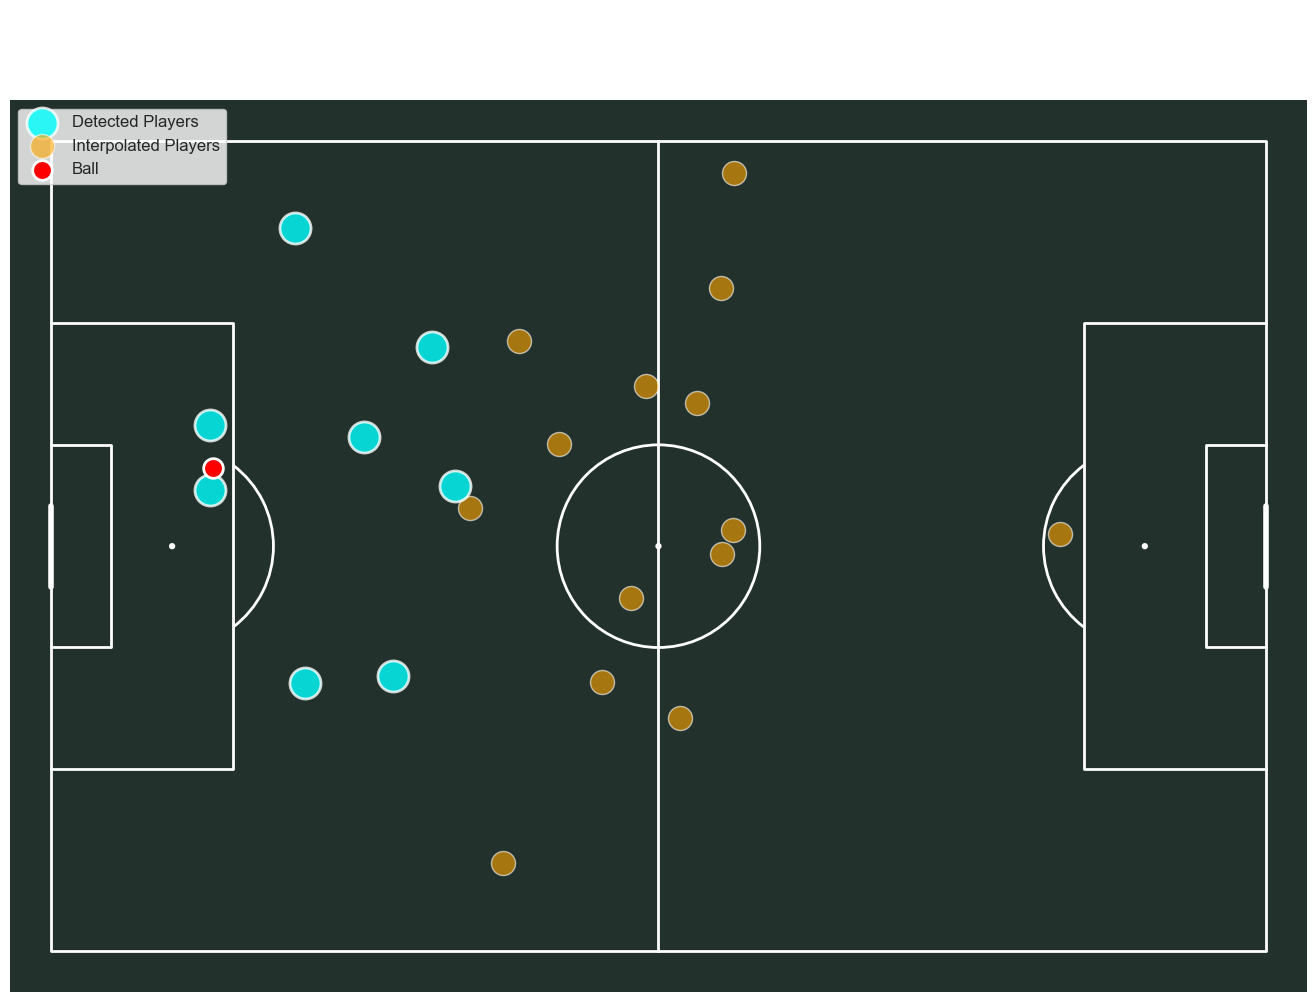


Player positions summary:
Total players: 22
Detected: 8
Interpolated: 14


In [13]:
# Select a goal kick frame
if len(goal_kick_frames) > 0:
    selected_idx = goal_kick_frames.index[0]
    selected_frame = freeze_frames[selected_idx]
    
    print(f"Visualizing Goal Kick:")
    print(f"Frame: {selected_frame['frame']}")
    print(f"Timestamp: {selected_frame['timestamp']}")
    print(f"Event Type: {selected_frame['statsbomb_event_type']}")
    print(f"Event ID: {selected_frame['statsbomb_event_id']}")
    print(f"Number of players: {len(selected_frame['player_data'])}")
    
    # Convert player positions to StatsBomb coordinates
    players = []
    for p in selected_frame['player_data']:
        x_sb, y_sb = skillcorner_to_statsbomb(p['x'], p['y'])
        players.append({
            'player_id': p['player_id'],
            'x': x_sb,
            'y': y_sb,
            'is_detected': p['is_detected'],
            'speed': p['speed_norm']
        })
    
    players_df = pd.DataFrame(players)
    
    # Convert ball position
    ball_x_sb, ball_y_sb = skillcorner_to_statsbomb(
        selected_frame['ball_data']['x'],
        selected_frame['ball_data']['y']
    )
    
    # Create pitch visualization
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
    fig, ax = pitch.draw(figsize=(14, 10))
    
    # Plot detected players (larger)
    detected = players_df[players_df['is_detected']]
    pitch.scatter(detected['x'], detected['y'], 
                 s=500, c='cyan', edgecolors='white', linewidth=2,
                 alpha=0.8, ax=ax, zorder=3, label='Detected Players')
    
    # Plot undetected players (smaller, different color)
    undetected = players_df[~players_df['is_detected']]
    pitch.scatter(undetected['x'], undetected['y'], 
                 s=300, c='orange', edgecolors='white', linewidth=1,
                 alpha=0.6, ax=ax, zorder=2, label='Interpolated Players')
    
    # Plot ball
    pitch.scatter(ball_x_sb, ball_y_sb, 
                 s=200, c='red', edgecolors='white', linewidth=2,
                 marker='o', ax=ax, zorder=4, label='Ball')
    
    # Add legend
    ax.legend(loc='upper left', fontsize=12)
    
    # Title
    ax.set_title(f'Goal Kick - All 22 Player Positions\n'
                f'{selected_frame["timestamp"]} (Period {selected_frame["period"]})\n'
                f'{len(detected)} detected, {len(undetected)} interpolated',
                fontsize=16, color='white', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\nPlayer positions summary:")
    print(f"Total players: {len(players_df)}")
    print(f"Detected: {len(detected)}")
    print(f"Interpolated: {len(undetected)}")
else:
    print("No goal kick frames found!")

## 9. Find Goal Kick with OBV and Visualize

In [15]:
# Merge freeze frame data with elastic data to get OBV values
# First, check what columns elastic_df has
print("Checking elastic_df columns...")
print(f"Total columns: {len(elastic_df.columns)}")
print(f"\nFirst 10 columns: {elastic_df.columns[:10].tolist()}")

# Find the event ID column - it might be named differently
id_candidates = [col for col in elastic_df.columns if 'id' in col.lower() and 'player' not in col.lower()]
print(f"\nPotential ID columns: {id_candidates}")

# The event ID is likely just at the top level without prefix
# Check if it exists as a column
if 'id' in elastic_df.columns:
    id_column = 'id'
elif 'event_id' in elastic_df.columns:
    id_column = 'event_id'
else:
    # Try to find it in the normalized columns
    id_column = [col for col in id_candidates if col.split('.')[-1] == 'id'][0] if id_candidates else None

print(f"\nUsing ID column: {id_column}")

# Prepare freeze frame data
freeze_summary_with_id = freeze_summary.copy()
freeze_summary_with_id['event_id'] = freeze_summary_with_id['event_id'].astype(str)

# Select columns that exist in elastic_df
obv_cols = [col for col in elastic_df.columns if 'obv' in col.lower()]
pattern_cols = [col for col in elastic_df.columns if 'play_pattern' in col]
outcome_cols = [col for col in elastic_df.columns if 'pass.outcome' in col]

merge_cols = [id_column] + obv_cols + pattern_cols + outcome_cols
print(f"\nColumns to merge: {merge_cols}")

# Ensure ID column is string type
elastic_df[id_column] = elastic_df[id_column].astype(str)

# Merge
merged = freeze_summary_with_id.merge(
    elastic_df[merge_cols],
    left_on='event_id', right_on=id_column, how='left'
)

# Find the play_pattern column name
play_pattern_col = [col for col in merged.columns if 'play_pattern' in col and 'name' in col]
if play_pattern_col:
    play_pattern_col = play_pattern_col[0]
    
    # Filter for actual goal kicks
    goal_kicks = merged[
        (merged[play_pattern_col] == 'From Goal Kick') &
        (merged['event_type'] == 'Pass')
    ].copy()
else:
    print("Warning: Could not find play_pattern column, using coordinate-based filtering")
    # Fallback: use coordinate-based filtering from earlier
    goal_kicks = merged[
        (merged['event_type'] == 'Pass') &
        (merged['ball_x'] < -30)
    ].copy()

print(f"\nNumber of goal kick passes with OBV: {len(goal_kicks)}")

# Display results with available columns
obv_total_col = [col for col in goal_kicks.columns if 'obv_total_net' in col]
outcome_col = [col for col in goal_kicks.columns if 'outcome' in col and 'name' in col]

display_cols = ['timestamp', 'event_type']
if obv_total_col:
    display_cols.append(obv_total_col[0])
if outcome_col:
    display_cols.append(outcome_col[0])

print("\nGoal kicks with OBV values:")
print(goal_kicks[display_cols].head(10))

Checking elastic_df columns...
Total columns: 197

First 10 columns: ['timestamp', 'period', 'event_id', 'event_type', 'team_id', 'team_name', 'player_id', 'player_name', 'x', 'y']

Potential ID columns: ['event_id', 'team_id', 'tracking_frame_id', 'tracking_team_id', 'statsbomb_match_id', 'skillcorner_match_id', 'statsbomb_data.id', 'statsbomb_data.type.id', 'statsbomb_data.possession_team.id', 'statsbomb_data.play_pattern.id', 'statsbomb_data.team.id', 'statsbomb_data.match_id', 'statsbomb_data.position.id', 'statsbomb_data.pass.recipient.id', 'statsbomb_data.pass.height.id', 'statsbomb_data.pass.body_part.id', 'statsbomb_data.pass.type.id', 'statsbomb_data.pass.pass_cluster_id', 'statsbomb_data.pass.outcome.id', 'statsbomb_data.duel.type.id', 'statsbomb_data.clearance.body_part.id', 'statsbomb_data.ball_receipt.outcome.id', 'statsbomb_data.shot.technique.id', 'statsbomb_data.shot.body_part.id', 'statsbomb_data.shot.type.id', 'statsbomb_data.shot.outcome.id', 'statsbomb_data.goalkeep

## 10. Visualize Goal Kick with Highest OBV

Best Goal Kick:
Timestamp: 01:15:10.80
OBV Total Net: 0.0297
Number of players: 22


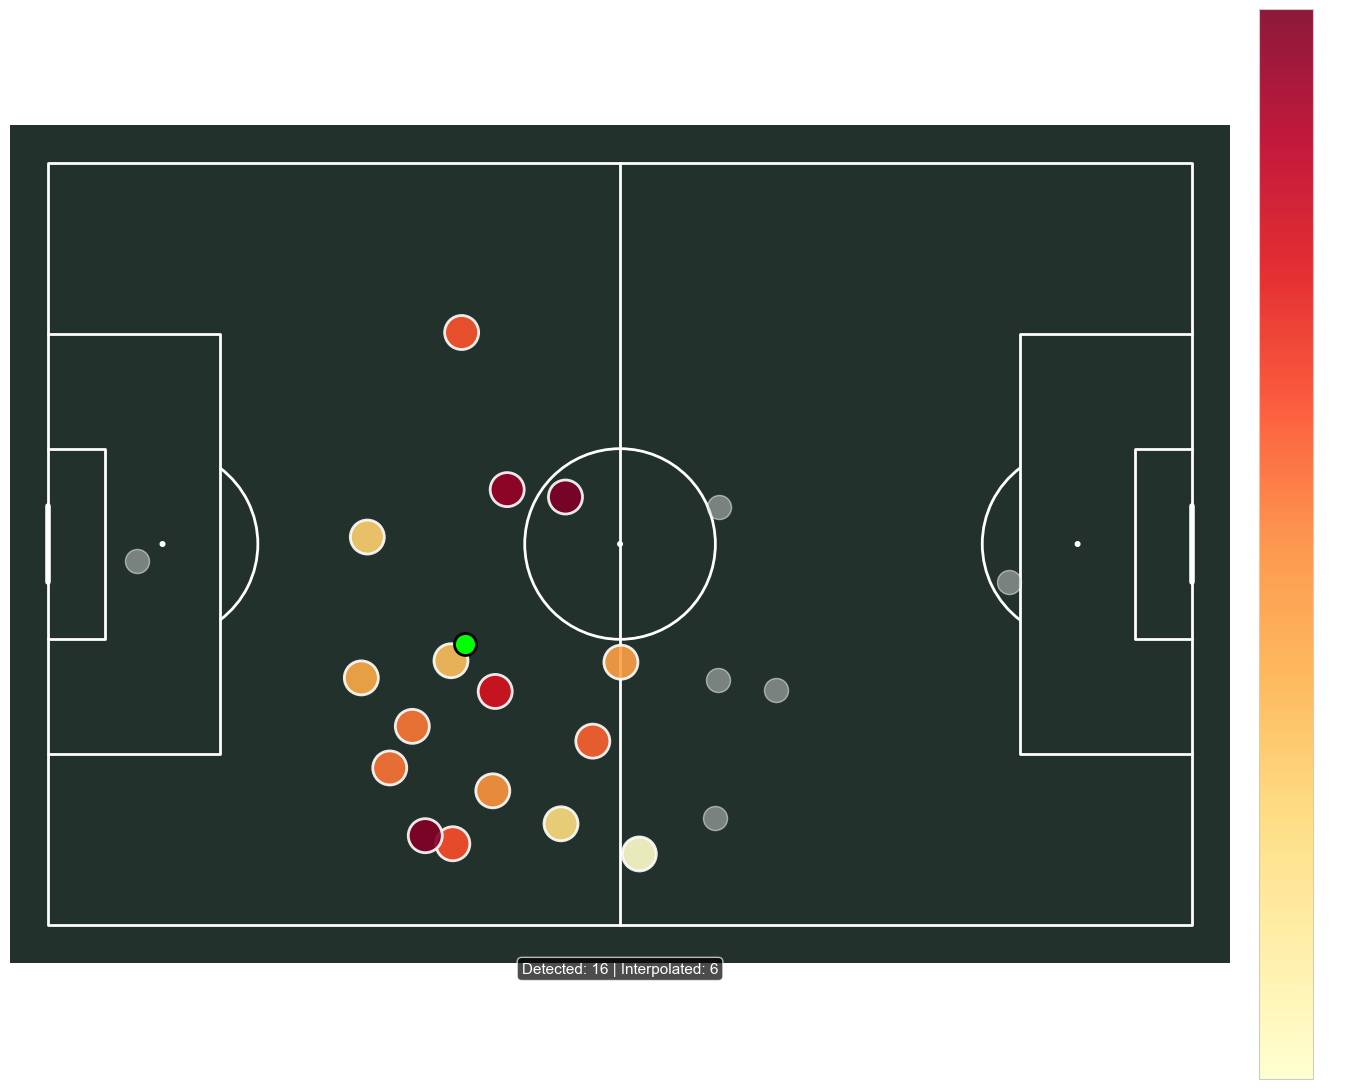


✅ Successfully visualized all 22 player positions!


In [16]:
# Find goal kick with highest positive OBV
if len(goal_kicks) > 0:
    # Find the OBV total net column
    obv_total_col = [col for col in goal_kicks.columns if 'obv_total_net' in col]
    
    if obv_total_col:
        obv_total_col = obv_total_col[0]
        goal_kicks_with_obv = goal_kicks.dropna(subset=[obv_total_col])
    else:
        print("No OBV column found!")
        goal_kicks_with_obv = pd.DataFrame()
    
    if len(goal_kicks_with_obv) > 0:
        best_goal_kick = goal_kicks_with_obv.loc[
            goal_kicks_with_obv[obv_total_col].idxmax()
        ]
        
        # Get the freeze frame for this event
        best_frame_idx = best_goal_kick.name
        best_frame = freeze_frames[best_frame_idx]
        
        obv_value = best_goal_kick[obv_total_col]
        
        print(f"Best Goal Kick:")
        print(f"Timestamp: {best_frame['timestamp']}")
        print(f"OBV Total Net: {obv_value:.4f}")
        print(f"Number of players: {len(best_frame['player_data'])}")
        
        # Convert coordinates
        players = []
        for p in best_frame['player_data']:
            x_sb, y_sb = skillcorner_to_statsbomb(p['x'], p['y'])
            players.append({
                'player_id': p['player_id'],
                'x': x_sb,
                'y': y_sb,
                'is_detected': p['is_detected'],
                'speed': p['speed_norm']
            })
        
        players_df = pd.DataFrame(players)
        
        ball_x_sb, ball_y_sb = skillcorner_to_statsbomb(
            best_frame['ball_data']['x'],
            best_frame['ball_data']['y']
        )
        
        # Create visualization
        pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
        fig, ax = pitch.draw(figsize=(15, 11))
        
        # Plot players with speed-based coloring for detected players
        detected = players_df[players_df['is_detected']]
        undetected = players_df[~players_df['is_detected']]
        
        # Scatter plot for detected players colored by speed
        scatter = pitch.scatter(detected['x'], detected['y'], 
                               s=600, c=detected['speed'], 
                               cmap='YlOrRd', edgecolors='white', linewidth=2,
                               alpha=0.9, ax=ax, zorder=3)
        
        # Add colorbar
        cbar = plt.colorbar(scatter, ax=ax, pad=0.02)
        cbar.set_label('Speed (m/s)', color='white', fontsize=12)
        cbar.ax.yaxis.set_tick_params(color='white')
        plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
        
        # Plot undetected players
        pitch.scatter(undetected['x'], undetected['y'], 
                     s=300, c='lightgray', edgecolors='white', linewidth=1,
                     alpha=0.5, ax=ax, zorder=2)
        
        # Plot ball
        pitch.scatter(ball_x_sb, ball_y_sb, 
                     s=250, c='lime', edgecolors='black', linewidth=2,
                     marker='o', ax=ax, zorder=4)
        
        # Add text for player count
        ax.text(60, 85, f'Detected: {len(detected)} | Interpolated: {len(undetected)}',
               fontsize=11, color='white', ha='center',
               bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))
        
        # Title
        ax.set_title(f'Goal Kick with Highest OBV = {obv_value:.4f}\n'
                    f'{best_frame["timestamp"]} (Period {best_frame["period"]})\n'
                    f'Player positions at moment of pass',
                    fontsize=16, color='white', pad=20, fontweight='bold')
        
        plt.tight_layout()
        plt.show()
        
        print("\n✅ Successfully visualized all 22 player positions!")
    else:
        print("No goal kicks with OBV values found")
else:
    print("No goal kick passes found")

## 11. Compare Multiple Goal Kicks

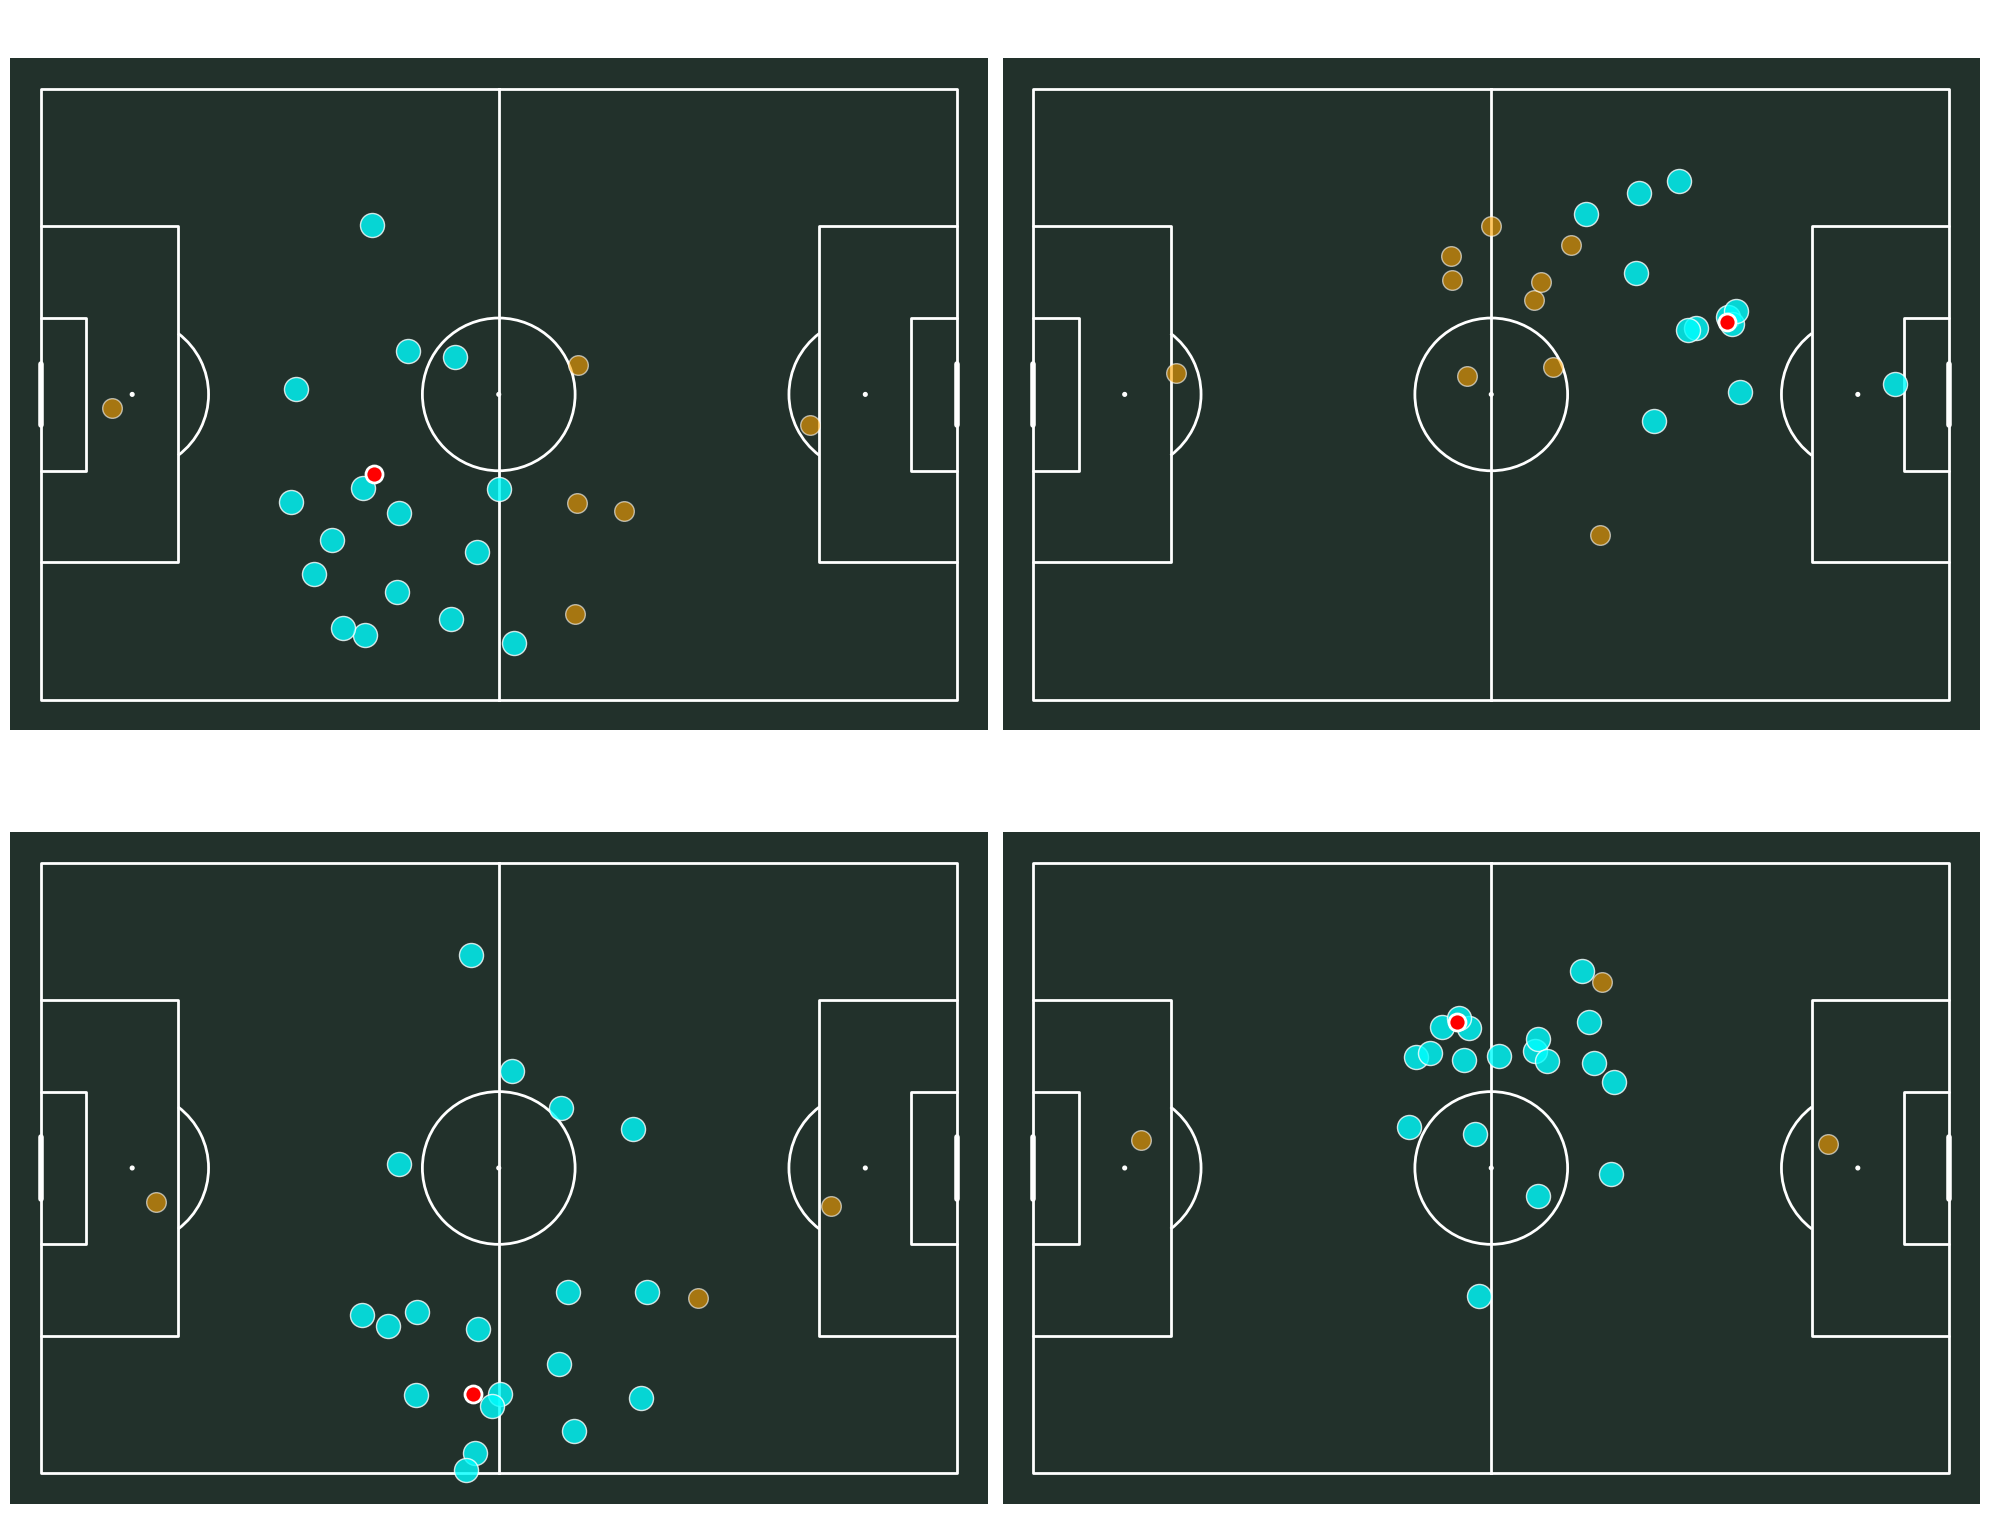

In [17]:
# Create a grid of goal kick visualizations
if 'goal_kicks_with_obv' in locals() and len(goal_kicks_with_obv) >= 4:
    # Find OBV column
    obv_total_col = [col for col in goal_kicks_with_obv.columns if 'obv_total_net' in col][0]
    
    # Select 4 goal kicks: highest OBV, lowest OBV, and 2 random
    selected_gks = [
        goal_kicks_with_obv[obv_total_col].idxmax(),  # Best
        goal_kicks_with_obv[obv_total_col].idxmin(),  # Worst
    ]
    # Add 2 random
    remaining = goal_kicks_with_obv.drop(selected_gks)
    if len(remaining) >= 2:
        selected_gks.extend(remaining.sample(2).index.tolist())
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))
    axes = axes.flatten()
    
    for idx, gk_idx in enumerate(selected_gks):
        gk_row = goal_kicks_with_obv.loc[gk_idx]
        gk_frame = freeze_frames[gk_idx]
        obv = gk_row[obv_total_col]
        
        # Convert coordinates
        players = []
        for p in gk_frame['player_data']:
            x_sb, y_sb = skillcorner_to_statsbomb(p['x'], p['y'])
            players.append({'x': x_sb, 'y': y_sb, 'is_detected': p['is_detected']})
        players_df = pd.DataFrame(players)
        
        ball_x_sb, ball_y_sb = skillcorner_to_statsbomb(
            gk_frame['ball_data']['x'], gk_frame['ball_data']['y']
        )
        
        # Plot
        pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
        pitch.draw(ax=axes[idx])
        
        detected = players_df[players_df['is_detected']]
        undetected = players_df[~players_df['is_detected']]
        
        pitch.scatter(detected['x'], detected['y'], s=300, c='cyan',
                     edgecolors='white', linewidth=1, alpha=0.8, ax=axes[idx], zorder=3)
        pitch.scatter(undetected['x'], undetected['y'], s=200, c='orange',
                     edgecolors='white', linewidth=1, alpha=0.6, ax=axes[idx], zorder=2)
        pitch.scatter(ball_x_sb, ball_y_sb, s=150, c='red',
                     edgecolors='white', linewidth=2, ax=axes[idx], zorder=4)
        
        axes[idx].set_title(f'Goal Kick at {gk_frame["timestamp"]}\nOBV = {obv:.4f}',
                           fontsize=14, color='white', pad=10)
    
    plt.tight_layout()
    plt.show()
elif 'goal_kicks_with_obv' in locals():
    print(f"Only {len(goal_kicks_with_obv)} goal kicks available")
else:
    print("No goal kicks with OBV data available")

## 12. Visualize Goal Kick Possession Sequence

Show a sequence of events within one goal kick possession, with only the players involved in each action. Use arrows for passes, dotted lines for carries, and color-code by team.

In [33]:
# First, let's identify goal kick possessions from the elastic data
from matplotlib.patches import FancyArrowPatch

# Find goal kick possessions (sequences of events)
goal_kick_events = elastic_df[
    (elastic_df['statsbomb_data.play_pattern.name'] == 'From Goal Kick') &
    (elastic_df['statsbomb_data.type.name'] != 'Half Start')
].copy()

# Group by possession to find sequences
goal_kick_events['possession'] = goal_kick_events['statsbomb_data.possession']

# DIAGNOSTIC: Check possession distribution
possession_counts = goal_kick_events.groupby('possession').size()
print(f"\n{'='*60}")
print(f"DIAGNOSTIC: Possession Analysis")
print(f"{'='*60}")
print(f"Total goal kick events found: {len(goal_kick_events)}")
print(f"Number of unique possessions: {len(possession_counts)}")
print(f"\nTop 10 possessions by event count:")
print(possession_counts.sort_values(ascending=False).head(10))

# Find possession with most events (longest sequence)
best_possession = possession_counts.idxmax()
sequence_events = goal_kick_events[goal_kick_events['possession'] == best_possession].copy()

# Sort by timestamp
sequence_events = sequence_events.sort_values('statsbomb_data.timestamp')

print(f"\n{'='*60}")
print(f"Selected Possession: {best_possession}")
print(f"{'='*60}")

# DIAGNOSTIC: Verify all events are "From Goal Kick"
pattern_check = sequence_events['statsbomb_data.play_pattern.name'].value_counts()
print(f"\nPlay patterns in this possession:")
for pattern, count in pattern_check.items():
    print(f"  {pattern}: {count} events")

# DIAGNOSTIC: Check time span
timestamps = sequence_events['statsbomb_data.timestamp'].values
time_span = timestamps[-1] - timestamps[0] if len(timestamps) > 1 else 0
print(f"\nTime span: {timestamps[0]} to {timestamps[-1]}")
print(f"Duration: {time_span:.1f} seconds")

# DIAGNOSTIC: Show unique team involvement
teams_involved = sequence_events['statsbomb_data.team.name'].value_counts()
print(f"\nTeam event counts:")
for team, count in teams_involved.items():
    print(f"  {team}: {count} events")

print(f"\nTotal events in possession: {len(sequence_events)}")
print(f"\nFirst 20 events in sequence:")
for idx, row in sequence_events.head(20).iterrows():
    event_type = row['statsbomb_data.type.name']
    player = row.get('statsbomb_data.player.name', 'Unknown')
    team = row.get('statsbomb_data.team.name', 'Unknown')
    timestamp = row['statsbomb_data.timestamp']
    pattern = row['statsbomb_data.play_pattern.name']
    obv = row.get('statsbomb_data.obv.obv_total_net', 0.0)
    print(f"  {timestamp:6.1f}s | {event_type:15s} | {player:20.20s} | {team[:12]:12s} | {pattern} | OBV: {obv:+.4f}")


DIAGNOSTIC: Possession Analysis
Total goal kick events found: 390
Number of unique possessions: 12

Top 10 possessions by event count:
possession
129    146
11     109
132     32
33      19
90      18
125     17
49      13
150      9
52       8
136      8
dtype: int64

Selected Possession: 129

Play patterns in this possession:
  From Goal Kick: 146 events

Time span: 1772584186063 to 1772584310550
Duration: 124487.0 seconds

Team event counts:
  Nagoya Grampus: 121 events
  Kashima Antlers: 25 events

Total events in possession: 146

First 20 events in sequence:
  1772584186063.0s | Pass            | Mitchell James Lange | Nagoya Gramp | From Goal Kick | OBV: +0.0000
  1772584186663.0s | Ball Receipt*   | Kennedy Egbus Mikuni | Nagoya Gramp | From Goal Kick | OBV: +0.0000
  1772584186663.0s | Carry           | Kennedy Egbus Mikuni | Nagoya Gramp | From Goal Kick | OBV: +0.0000
  1772584190740.0s | Pass            | Kennedy Egbus Mikuni | Nagoya Gramp | From Goal Kick | OBV: +0.0000
 

In [34]:
# Get freeze frames for these events and prepare visualization data
# First, let's debug what columns we actually have
print("\nDebugging columns:")
print(f"All columns: {list(sequence_events.columns[:20])}")

location_cols = [col for col in sequence_events.columns if 'location' in col.lower()]
print(f"Location columns: {location_cols[:10]}")

# Find the ID column dynamically
id_candidates = [col for col in sequence_events.columns if 'id' in col.lower() and 'player' not in col.lower() and 'team' not in col.lower()]
print(f"ID candidates: {id_candidates[:5]}")

if 'id' in sequence_events.columns:
    id_col = 'id'
elif 'statsbomb_data.id' in sequence_events.columns:
    id_col = 'statsbomb_data.id'
elif id_candidates:
    id_col = id_candidates[0]
else:
    id_col = None

print(f"Using ID column: {id_col}")

sequence_data = []

for idx, row in sequence_events.iterrows():
    event_id = str(row[id_col]) if id_col else str(idx)
    
    # Find matching freeze frame
    freeze_match = freeze_summary[freeze_summary['event_id'] == event_id]
    
    if len(freeze_match) > 0:
        freeze_idx = freeze_match.index[0]
        freeze_frame = freeze_frames[freeze_idx]
        
        # Get event details
        event_type = row['statsbomb_data.type.name']
        team_name = row.get('statsbomb_data.team.name', 'Unknown')
        player_name = row.get('statsbomb_data.player.name', 'Unknown')
        
        # Extract start location
        start_loc = None
        if 'statsbomb_data.location' in sequence_events.columns:
            loc_data = row.get('statsbomb_data.location')
            if loc_data is not None and not (isinstance(loc_data, float) and pd.isna(loc_data)):
                if isinstance(loc_data, (list, tuple)) and len(loc_data) >= 2:
                    start_loc = [float(loc_data[0]), float(loc_data[1])]
        
        # Get end location for passes
        end_loc = None
        if 'statsbomb_data.pass.end_location' in sequence_events.columns:
            end_data = row.get('statsbomb_data.pass.end_location')
            if end_data is not None and not (isinstance(end_data, float) and pd.isna(end_data)):
                if isinstance(end_data, (list, tuple)) and len(end_data) >= 2:
                    end_loc = [float(end_data[0]), float(end_data[1])]
        
        # If no pass end location, try carry
        if end_loc is None and 'statsbomb_data.carry.end_location' in sequence_events.columns:
            end_data = row.get('statsbomb_data.carry.end_location')
            if end_data is not None and not (isinstance(end_data, float) and pd.isna(end_data)):
                if isinstance(end_data, (list, tuple)) and len(end_data) >= 2:
                    end_loc = [float(end_data[0]), float(end_data[1])]
        
        # Get player position from freeze frame
        player_id = row.get('statsbomb_data.player.id', None)
        team_id = row.get('statsbomb_data.team.id', None)
        
        # Find player in freeze frame
        player_pos = None
        for p in freeze_frame['player_data']:
            if str(p['player_id']) == str(player_id):
                player_pos = skillcorner_to_statsbomb(p['x'], p['y'])
                break
        
        sequence_data.append({
            'event_type': event_type,
            'team_name': team_name,
            'team_id': team_id,
            'player_name': player_name,
            'player_id': player_id,
            'start_loc': start_loc,
            'end_loc': end_loc,
            'player_pos': player_pos,
            'obv': row.get('statsbomb_data.obv.obv_total_net', 0.0),
            'timestamp': row['statsbomb_data.timestamp']
        })

print(f"\nSuccessfully matched {len(sequence_data)} events with freeze frames")

# Debug: Show what's in the first row
if len(sequence_data) > 0:
    print("\nFirst event data sample:")
    first = sequence_data[0]
    print(f"  Event type: {first['event_type']}")
    print(f"  Player: {first['player_name']}")
    print(f"  Start location: {first['start_loc']}")
    print(f"  End location: {first['end_loc']}")
    print(f"  Player position: {first['player_pos']}")
    
    # Show some actual data from first row to debug
    print("\nDebug - first row sample columns:")
    first_row = sequence_events.iloc[0]
    print(f"  Event ID used: {first_row[id_col] if id_col else 'N/A'}")
    if 'statsbomb_data.location' in sequence_events.columns:
        print(f"  Raw location data: {first_row['statsbomb_data.location']}")
        print(f"  Location type: {type(first_row['statsbomb_data.location'])}")
    if 'statsbomb_data.pass.end_location' in sequence_events.columns:
        print(f"  Raw pass end_location: {first_row['statsbomb_data.pass.end_location']}")
    if 'statsbomb_data.player.id' in sequence_events.columns:
        print(f"  Player ID: {first_row['statsbomb_data.player.id']}")


Debugging columns:
All columns: ['timestamp', 'period', 'event_id', 'event_type', 'team_id', 'team_name', 'player_id', 'player_name', 'x', 'y', 'tracking_timestamp', 'tracking_period', 'tracking_frame_id', 'tracking_team_id', 'tracking_player_id', 'tracking_jersey_number', 'tracking_x', 'tracking_y', 'tracking_spatial_distance', 'tracking_temporal_distance']
Location columns: ['statsbomb_data.location', 'statsbomb_data.pass.end_location', 'statsbomb_data.carry.end_location', 'statsbomb_data.shot.end_location', 'statsbomb_data.goalkeeper.end_location']
ID candidates: ['event_id', 'tracking_frame_id', 'statsbomb_match_id', 'skillcorner_match_id', 'statsbomb_data.id']
Using ID column: statsbomb_data.id

Successfully matched 146 events with freeze frames

First event data sample:
  Event type: Pass
  Player: Mitchell James Langerak
  Start location: [4.5, 45.2]
  End location: [6.1, 50.1]
  Player position: None

Debug - first row sample columns:
  Event ID used: 3d8cb12f-f37d-4e70-b611-0


Action type breakdown for this possession:
  Pass                :  45
  Ball Receipt*       :  44
  Carry               :  34
  Pressure            :  17
  Block               :   2
  Clearance           :   2
  Interception        :   1
  Ball Recovery       :   1
  ─────────────────────────
  Total events        : 146

Team colors:
  Nagoya Grampus: cyan
  Kashima Antlers: orange

Plotting 146 events...

Event 1: Pass by Mitchell James Langerak
  Start: [4.5, 45.2], End: [6.1, 50.1], Player pos: None
  ✓ Plotted pass arrow from (4.5, 45.2) to (6.1, 50.1)

Event 2: Ball Receipt* by Kennedy Egbus Mikuni
  Start: [6.1, 50.1], End: None, Player pos: None

Event 3: Carry by Kennedy Egbus Mikuni
  Start: [6.1, 50.1], End: [14.7, 47.8], Player pos: None

Event 4: Pass by Kennedy Egbus Mikuni
  Start: [14.7, 47.8], End: [19.4, 30.7], Player pos: None
  ✓ Plotted pass arrow from (14.7, 47.8) to (19.4, 30.7)

Event 5: Ball Receipt* by Shion Inoue
  Start: [19.4, 30.7], End: None, Player pos:

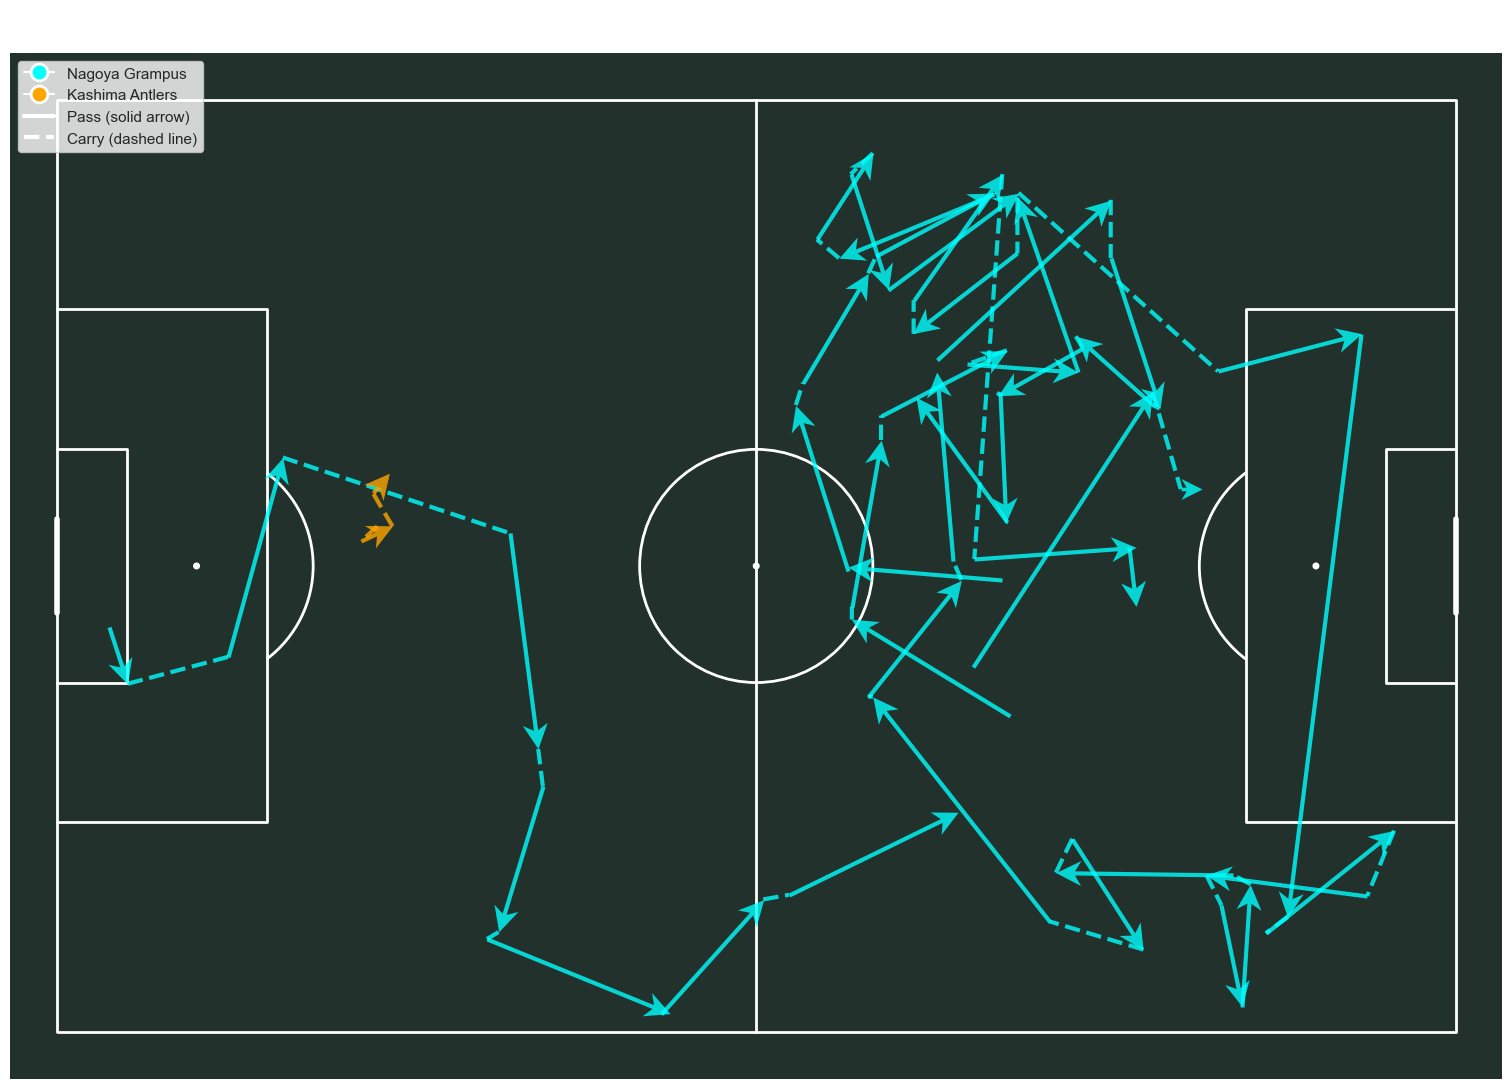


Event details:
1. Pass            by Mitchell James Langerak   (Nagoya Grampus ) OBV: +0.0000
2. Ball Receipt*   by Kennedy Egbus Mikuni      (Nagoya Grampus ) OBV: +0.0000
3. Carry           by Kennedy Egbus Mikuni      (Nagoya Grampus ) OBV: +0.0000
4. Pass            by Kennedy Egbus Mikuni      (Nagoya Grampus ) OBV: +0.0000
5. Ball Receipt*   by Shion Inoue               (Nagoya Grampus ) OBV: +0.0000
6. Carry           by Shion Inoue               (Nagoya Grampus ) OBV: +0.0000
7. Pass            by Shion Inoue               (Nagoya Grampus ) OBV: +0.0000
8. Carry           by Kennedy Egbus Mikuni      (Nagoya Grampus ) OBV: +0.0000
9. Ball Receipt*   by Kennedy Egbus Mikuni      (Nagoya Grampus ) OBV: +0.0000
10. Pass            by Kennedy Egbus Mikuni      (Nagoya Grampus ) OBV: +0.0000
11. Ball Receipt*   by Yuki Nogami               (Nagoya Grampus ) OBV: +0.0000
12. Carry           by Yuki Nogami               (Nagoya Grampus ) OBV: +0.0000
13. Pressure        by Hayato Nak

In [32]:
# Count action types in the sequence
from collections import Counter
action_counts = Counter([event['event_type'] for event in sequence_data])
print(f"\nAction type breakdown for this possession:")
for action, count in action_counts.most_common():
    print(f"  {action:20s}: {count:3d}")
print(f"  {'─' * 25}")
print(f"  {'Total events':20s}: {len(sequence_data):3d}")

# Create the visualization
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
fig, ax = pitch.draw(figsize=(16, 11))

# Identify unique teams and assign colors
teams = sequence_events['statsbomb_data.team.id'].unique()
team_colors = {teams[0]: 'cyan', teams[1]: 'orange'}

# Get team names for legend
team_names = {}
for team_id in teams:
    team_name = sequence_events[sequence_events['statsbomb_data.team.id'] == team_id]['statsbomb_data.team.name'].iloc[0]
    team_names[team_id] = team_name

print(f"\nTeam colors:")
for team_id, color in team_colors.items():
    print(f"  {team_names[team_id]}: {color}")

# Plot the sequence
print(f"\nPlotting {len(sequence_data)} events...")
num_plotted_players = 0
num_plotted_actions = 0

for i, event in enumerate(sequence_data):
    team_id = event['team_id']
    color = team_colors.get(team_id, 'white')
    event_type = event['event_type']
    start_loc = event['start_loc']
    end_loc = event['end_loc']
    
    print(f"\nEvent {i+1}: {event_type} by {event['player_name']}")
    print(f"  Start: {start_loc}, End: {end_loc}, Player pos: {event['player_pos']}")
    
    # Plot player position
    if event['player_pos']:
        x, y = event['player_pos']
        pitch.scatter(x, y, s=500, c=color, edgecolors='white', linewidth=2,
                     alpha=0.9, ax=ax, zorder=10+i)
        
        # Add event number
        ax.text(x, y, str(i+1), fontsize=12, fontweight='bold',
               ha='center', va='center', color='black', zorder=11+i)
        num_plotted_players += 1
        print(f"  ✓ Plotted player at ({x:.1f}, {y:.1f})")
    
    # Draw action lines
    if start_loc and end_loc:
        x_start, y_start = start_loc
        x_end, y_end = end_loc
        
        if event_type == 'Pass':
            # Solid arrow for passes
            pitch.arrows(x_start, y_start, x_end, y_end,
                        width=3, headwidth=6, headlength=6,
                        color=color, alpha=0.8, ax=ax, zorder=5)
            num_plotted_actions += 1
            print(f"  ✓ Plotted pass arrow from ({x_start:.1f}, {y_start:.1f}) to ({x_end:.1f}, {y_end:.1f})")
        elif event_type == 'Carry':
            # Dotted line for carries
            pitch.lines(x_start, y_start, x_end, y_end,
                       color=color, linestyle='--', linewidth=3,
                       alpha=0.8, ax=ax, zorder=5)
        else:
            # Thin line for other actions
            pitch.lines(x_start, y_start, x_end, y_end,
                       color=color, linestyle='-', linewidth=2,
                       alpha=0.6, ax=ax, zorder=4)

# Add legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=team_colors[teams[0]], 
           markersize=12, label=team_names[teams[0]], markeredgecolor='white', markeredgewidth=2),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=team_colors[teams[1]], 
           markersize=12, label=team_names[teams[1]], markeredgecolor='white', markeredgewidth=2),
    Line2D([0], [0], color='white', linewidth=3, label='Pass (solid arrow)'),
    Line2D([0], [0], color='white', linewidth=3, linestyle='--', label='Carry (dashed line)')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.8)

# Add title
ax.set_title(f'Goal Kick Possession Sequence (Possession {best_possession})\\n'
            f'{len(sequence_data)} Events - Players Involved Only',
            fontsize=16, color='white', pad=20, fontweight='bold')

print(f"\nSummary: Plotted {num_plotted_players} players and {num_plotted_actions} actions")

plt.tight_layout()
plt.show()

# Print event details
print("\nEvent details:")
for i, event in enumerate(sequence_data):
    print(f"{i+1}. {event['event_type']:15s} by {event['player_name']:25s} "
          f"({event['team_name'][:15]:15s}) OBV: {event['obv']:+.4f}")

## 13. Animated Sequence with Event Annotations

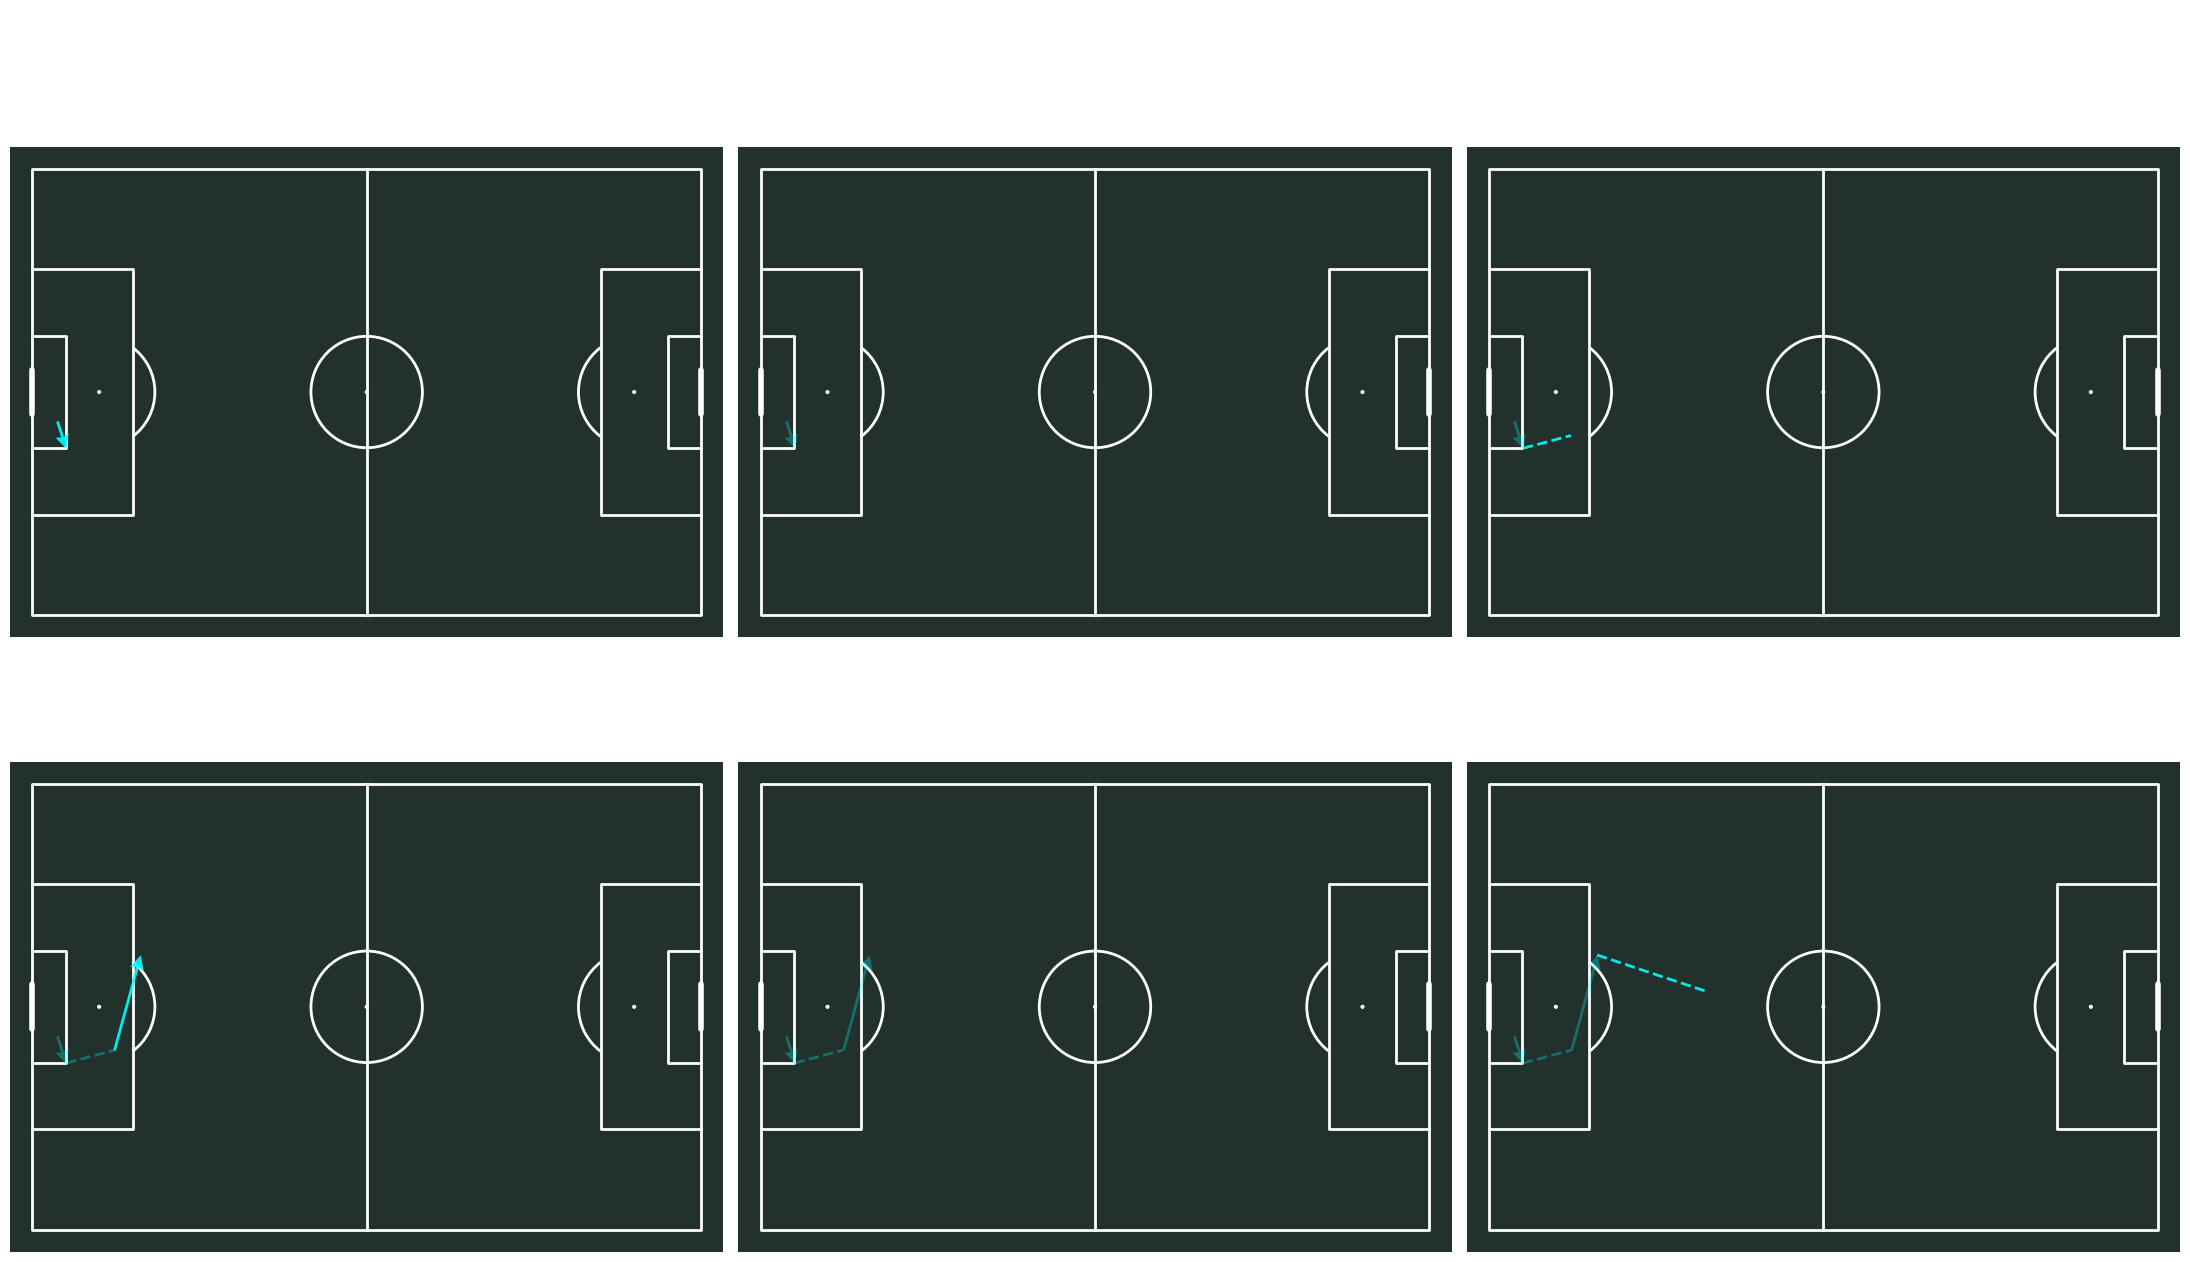

In [35]:
# Create individual frames for each event in the sequence
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
axes = axes.flatten()

# Plot each event step
for i, event in enumerate(sequence_data[:6]):  # Show first 6 events
    if i >= len(axes):
        break
    
    pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='white')
    pitch.draw(ax=axes[i])
    
    # Plot all previous events (faded)
    for j, prev_event in enumerate(sequence_data[:i+1]):
        team_id = prev_event['team_id']
        color = team_colors.get(team_id, 'white')
        alpha = 0.3 if j < i else 0.9
        
        # Player position
        if prev_event['player_pos']:
            x, y = prev_event['player_pos']
            pitch.scatter(x, y, s=400 if j == i else 200, c=color, 
                         edgecolors='white', linewidth=2 if j == i else 1,
                         alpha=alpha, ax=axes[i], zorder=10+j)
            
            if j == i:
                axes[i].text(x, y, str(j+1), fontsize=11, fontweight='bold',
                           ha='center', va='center', color='black', zorder=11+j)
        
        # Action lines
        if prev_event['start_loc'] and prev_event['end_loc']:
            x_start, y_start = prev_event['start_loc']
            x_end, y_end = prev_event['end_loc']
            
            if prev_event['event_type'] == 'Pass':
                pitch.arrows(x_start, y_start, x_end, y_end,
                            width=2, headwidth=5, headlength=5,
                            color=color, alpha=alpha, ax=axes[i], zorder=5)
            elif prev_event['event_type'] == 'Carry':
                pitch.lines(x_start, y_start, x_end, y_end,
                           color=color, linestyle='--', linewidth=2,
                           alpha=alpha, ax=axes[i], zorder=5)
    
    # Add event description
    obv_text = f"OBV: {event['obv']:+.4f}" if event['obv'] else ""
    axes[i].set_title(f"Event {i+1}: {event['event_type']}\\n"
                      f"{event['player_name'][:20]} ({event['team_name'][:12]})\\n{obv_text}",
                      fontsize=11, color='white', pad=10, fontweight='bold')

# Hide unused subplots
for i in range(len(sequence_data[:6]), len(axes)):
    axes[i].axis('off')

plt.suptitle(f'Goal Kick Sequence - Step by Step (Possession {best_possession})',
            fontsize=16, color='white', fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrates:
1. Loading freeze frame data with complete 22-player positioning
2. Converting SkillCorner coordinates to StatsBomb format
3. Merging with OBV data from elastic files
4. Visualizing player positions for goal kick events
5. Distinguishing between detected and interpolated player positions
6. **Animating goal kick possession sequences with team colors and action types**

**Key Findings:**
- Freeze frame files contain complete tactical snapshots at each event
- Player detection varies (some positions are interpolated)
- Can link to OBV values to analyze tactical setups for high-value actions
- Possession sequences show how the ball moves between players with different action types (passes vs carries)